# Laboratorio 1 — CH03: Análisis de Algoritmos

Ejercicios de Goodrich, Tamassia & Goldwasser.

## Ejercicio 1 — C-3.50

Sea $p(x)$ un polinomio de grado $n$, es decir,

$$p(x) = \sum_{i=0}^{n} a_i x^i$$

**(a)** Describa un algoritmo simple de tiempo $O(n^2)$ para calcular $p(x)$.

**(b)** Mejore el algoritmo anterior calculando $x^i$ de una forma más eficiente.

**(c)** Ahora considere la siguiente reescritura de $p(x)$:

$$p(x) = a_0 + x\big(a_1 + x\big(a_2 + x\big(a_3 + \cdots + x(a_{n-1} + x a_n)\cdots\big)\big)\big)$$

conocida como el **método de Horner**. Usando la notación big-Oh, caracterice el número de operaciones aritméticas que ejecuta este método.

### (a) Algoritmo $O(n^2)$

In [2]:
def p_cuadratico(a, x):
    suma = 0
    #grado = len(a)-1
    xi = 1
    for i in range(len(a)):
        suma += a[i]*xi
        xi *= x
        
    return suma

In [3]:
p_cuadratico([1,2,3],2)


17

### (b) Algoritmo mejorado

In [4]:
def p_mejorado(a, x):
    suma = 0
    xi = 1
    for i in range(len(a)):
        suma += a[i] * xi
        xi *= x
    return suma

p_mejorado([1,2,3],2)


17

### (c) Método de Horner

In [6]:
def horner(a, x):
    suma = a[-2] + x*a[-1]
    a1 = a[:-2]
    for i in a1[::-1]:
        suma = i+ x*suma
    return suma

In [7]:
horner([1,2,3],2)

17

### Verificación de resultados

Los tres algoritmos deben dar el mismo resultado para $p(x) = 3 + 2x + 5x^2 - x^3 + 4x^4$ evaluado en $x=2$.

In [8]:
# a = [a0, a1, a2, a3, a4] -> p(x) = 3 + 2x + 5x^2 - x^3 + 4x^4
a = [3, 2, 5, -1, 4]
x = 2

print("p_cuadratico:", p_cuadratico(a, x))
print("p_mejorado:  ", p_mejorado(a, x))
print("horner:      ", horner(a, x))

p_cuadratico: 83
p_mejorado:   83
horner:       83


## Ejercicio 2 — División sintética

La **división sintética** permite evaluar un polinomio $p(x) = \sum_{i=0}^{n} a_i x^i$ en un valor $x = r$, dividiendo $p(x)$ entre $(x - r)$: el residuo de esa división es exactamente $p(r)$.

Programe una función `division_sintetica(a, r)` que implemente este método para evaluar el polinomio en $r$.

**Pregunta:** ¿es este método igual al método de Horner de la parte (c)? Justifique su respuesta comparando ambos algoritmos.

In [9]:
def division_sintetica(a, r):
    n = len(a) - 1
    b = a[n]
    for i in range(n - 1, -1, -1):
        b = a[i] + r * b
    return b

### Verificación

`division_sintetica` debe dar el mismo resultado que `horner` para el mismo polinomio y el mismo valor de evaluación.

In [10]:
print("horner:              ", horner(a, x))
print("division_sintetica:  ", division_sintetica(a, x))

horner:               83
division_sintetica:   83


## Ejercicio 3 — Comparación de algoritmos

El número de operaciones ejecutadas por los algoritmos A y B es $n^2 + n$ y $\dfrac{n^3}{200}$, respectivamente.

Determine $n_0$ tal que A es mejor que B para $n \geq n_0$.

Haga una gráfica (similar a las del notebook `ch03_teoria.ipynb`) que muestre ambas funciones. Ajustar la gráfica como en el cuaderno de teoría.

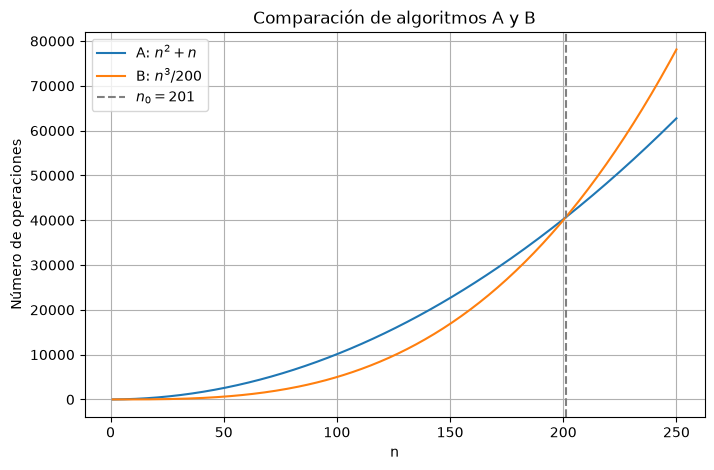

In [ ]:
# Comparé las dos fórmulas para ver en qué punto una empieza a ser mejor que la otra. 
# Al hacer el cálculo, me dio que el cambio ocurre alrededor de n = 201. Para comprobarlo, 
# probé con números concretos: con 200 elementos, el segundo algoritmo (B) todavía hace menos 
# operaciones que el primero (A). Pero con 201 elementos, ya es al revés: 
# A pasa a hacer menos operaciones que B. Por eso digo que a partir de n = 201, 
# el algoritmo A es el más conveniente.
import matplotlib.pyplot as plt
import numpy as np
n = np.arange(1, 251)
A = n**2 + n
B = n**3 / 200

plt.figure(figsize=(8, 5))
plt.plot(n, A, label='A: $n^2+n$')
plt.plot(n, B, label='B: $n^3/200$')
plt.axvline(x=201, color='gray', linestyle='--', label='$n_0=201$')
plt.xlabel('n')
plt.ylabel('Número de operaciones')
plt.title('Comparación de algoritmos A y B')
plt.legend()
plt.grid(True)
plt.show()

## Ejercicio 4 — Three-way set disjointness

Suponiendo que es posible ordenar $n$ números en tiempo $O(n\log n)$, demuestre que es posible resolver el problema de disyunción de tres conjuntos (**three-way set disjointness**) en tiempo $O(n\log n)$.

Programe una función `disjointness_nlogn(A, B, C)` que reciba tres secuencias de tamaño $n$ y retorne `True` si no existe ningún elemento común a las tres, usando ordenamiento en vez de los tres ciclos anidados de la versión $O(n^3)$.

In [13]:
def disjointness_nlogn(A, B, C):
    A_ord = sorted(A)
    B_ord= sorted(B)
    C_ord= sorted(C)
    i = 0
    j = 0
    k = 0
    
    while i < len(A_ord) and j < len(B_ord) and k < len(C_ord):
        a = A_ord[i]
        b = B_ord[j]
        c = C_ord[k]
        
        if a == b == c:
            return False 
        
        maximo = max(a, b, c)
        if a < maximo:
            i += 1
        if b < maximo:
            j += 1
        if c < maximo:
            k += 1
    
    return True

## Ejercicio 5 — R-3.28

Para cada función $f(n)$ y tiempo $t$ en la siguiente tabla, determine el tamaño más grande $n$ de un problema $P$ que puede resolverse en tiempo $t$ si el algoritmo que resuelve $P$ tarda $f(n)$ microsegundos (una entrada ya está completa).

| $f(n)$ | 1 Segundo | 1 Hora | 1 Mes | 1 Siglo |
|---|---|---|---|---|
| $\log n$ | $\approx 10^{300000}$ | | | |
| $n$ | | | | |
| $n\log n$ | | | | |
| $n^2$ | | | | |
| $2^n$ | | | | |

Complete la tabla. Puede apoyarse en una celda de código para hacer los cálculos.

In [14]:
seg = 10**6
hora = 3600 * seg
mes = 30 * 24 * 3600 * seg
siglo = 100 * 365 * 24 * 3600 * seg

tiempos = [("1 Segundo", seg), ("1 Hora", hora), ("1 Mes", mes), ("1 Siglo", siglo)]

def log2_aprox(valor):
    contador = 0
    while valor > 1:
        valor = valor / 2
        contador += 1
    return contador

for nombre, T in tiempos:
    print(nombre)
    print("  log n: n = 2^", T, "(un numero enorme)")
    print("  n:", T)
    
    n = 1
    while n * log2_aprox(n + 1) < T:
        n += max(1, n // 10)
    print("  n log n: aprox", n)
    
    print("  n^2:", int(T ** 0.5))
    print("  2^n:", log2_aprox(T))
    print()

1 Segundo
  log n: n = 2^ 1000000 (un numero enorme)
  n: 1000000
  n log n: aprox 64117
  n^2: 1000
  2^n: 20

1 Hora
  log n: n = 2^ 3600000000 (un numero enorme)
  n: 3600000000
  n log n: aprox 144459695
  n^2: 60000
  2^n: 32

1 Mes
  log n: n = 2^ 2592000000000 (un numero enorme)
  n: 2592000000000
  n log n: aprox 70838803200
  n^2: 1609968
  2^n: 42

1 Siglo
  log n: n = 2^ 3153600000000000 (un numero enorme)
  n: 3153600000000000
  n log n: aprox 74462434628423
  n^2: 56156922
  2^n: 52



## Ejercicio 6 — Valor más frecuente en un rango acotado

Una secuencia $S$ contiene $n$ enteros tomados del intervalo $[0, 4n]$, con repeticiones permitidas.

Describa un algoritmo eficiente para determinar un valor entero $k$ que ocurre con mayor frecuencia en $S$. ¿Cuál es el tiempo de ejecución de su algoritmo?

In [15]:
def valor_mas_frecuente(S, n):
    conteo = [0] * (4*n + 1)
    
    for numero in S:
        conteo[numero] = conteo[numero] + 1
    
    mejor_valor = 0
    mejor_conteo = 0
    for i in range(len(conteo)):
        if conteo[i] > mejor_conteo:
            mejor_conteo = conteo[i]
            mejor_valor = i
    
    return mejor_valor

## Ejercicio 7 — Búsqueda secuencial

Dada una lista $L$ de $n$ elementos (sin ordenar) y un valor $x$, programe una función `busqueda_secuencial(L, x)` que retorne `True` si $x$ se encuentra en $L$ y `False` en caso contrario, recorriendo la lista elemento por elemento.

Analice el mejor y el peor caso de este algoritmo usando notación big-Oh.

In [17]:
def busqueda_secuencial(L, x):
    for elemento in L:
        if elemento == x:
            return True
    return False

## Ejercicio 8 — Búsqueda binaria

Dada una lista $L$ **ordenada** de $n$ elementos y un valor $x$, programe una función `busqueda_binaria(L, x)` que retorne `True` si $x$ se encuentra en $L$ y `False` en caso contrario, descartando en cada paso la mitad de los elementos restantes.

¿Cuál es el tiempo de ejecución de este algoritmo, usando notación big-Oh? Compárelo con el de la búsqueda secuencial del ejercicio anterior.

In [18]:
def busqueda_binaria(L, x):
    inicio = 0
    fin = len(L) - 1
    while inicio <= fin:
        medio = (inicio + fin) // 2
        
        if L[medio] == x:
            return True
        elif L[medio] < x:
            inicio = medio + 1  # x esta en la mitad derecha
        else:
            fin = medio - 1  # x esta en la mitad izquierda
    
    return False
    pass